# House Price — Optimisation des Hyperparamètres & Modèle Final

Ce notebook :
1. **Ré-entraîne** les 5 meilleurs modèles avec les hyperparamètres optimaux trouvés par Optuna (60 trials chacun, loggués dans MLFlow)
2. **Construit** un VotingRegressor et un StackingRegressor sur les 4 meilleurs
3. **Analyse** le modèle final : résidus, feature importances
4. **Sauvegarde** le pipeline complet

> *Les hyperparamètres ont été déterminés par Optuna (voir MLFlow experiment `house_price_optimization`).*

In [1]:
import sys, warnings
warnings.filterwarnings("ignore")
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import mlflow
import dill
import pendulum
from loguru import logger

from sklearn.base import clone
from sklearn.linear_model import Ridge
from sklearn.ensemble import (RandomForestRegressor, StackingRegressor, VotingRegressor)
from sklearn.compose  import ColumnTransformer
from sklearn.impute   import SimpleImputer
from sklearn.pipeline import Pipeline, make_pipeline
from sklearn.preprocessing import RobustScaler, OneHotEncoder
from sklearn.model_selection import train_test_split, KFold
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score

from xgboost  import XGBRegressor
from lightgbm import LGBMRegressor
from catboost import CatBoostRegressor
import ppscore as pps

sys.path.append(str(Path.cwd().parent))
from settings.params import MODEL_PARAMS, MODEL_NAME, SEED
from src.make_dataset import load_data

pd.set_option("display.float_format", "{:.4f}".format)
TARGET = MODEL_PARAMS["TARGET"]
SEED   = 43
logger.info("Imports OK")

2026-06-08 12:21:29.187 | INFO     | __main__:<module>:36 - Imports OK


## 1. Données & features

In [2]:
data = load_data(dataset_name="house_prices", columns_to_lower=True)
data = data.astype({
    "overallqual": str, "overallcond": str, "garageyrblt": str,
    "yearbuilt": str, "yearremodadd": str, "mssubclass": str,
    "mosold": str, "yrsold": str,
})

COLS_TO_DROP = ["id", "yrsold", "yearbuilt", "yearremodadd", "garageyrblt"]
pps_df = pps.predictors(df=data.drop(COLS_TO_DROP, axis=1),
                         y=TARGET, output="df", random_seed=SEED)
FEATURE_NAMES = pps_df.loc[pps_df.ppscore.round(3) >= 0.05, "x"].values.tolist()

X = data[FEATURE_NAMES]
y_log = np.log1p(data[TARGET].astype(float))
y_raw = data[TARGET].astype(float)

X_train, X_test, y_log_train, y_log_test = train_test_split(
    X, y_log, test_size=0.2, random_state=SEED)
_, _, y_raw_train, y_raw_test = train_test_split(
    X, y_raw, test_size=0.2, random_state=SEED)

NUM_COLS = X_train.select_dtypes(include="number").columns.tolist()
CAT_COLS = X_train.select_dtypes(include=["object","bool"]).columns.tolist()
logger.info(f"Train: {X_train.shape} | Test: {X_test.shape} | Features: {len(FEATURE_NAMES)}")

2026-06-08 12:21:29.209 | INFO     | src.make_dataset:load_data:31 - Loaded house_prices dataset


2026-06-08 12:21:29.209 | INFO     | src.make_dataset:load_data:32 - dataset description : Ask a home buyer to describe their dream house, and they probably won't begin with the height of the basement ceiling or the proximity to an east-west railroad. But this playground competition's dataset proves that much more influences price negotiations than the number of bedrooms or a white-picket fence.

With 79 explanatory variables describing (almost) every aspect of residential homes in Ames, Iowa, this competition challenges you to predict the final price of each home.

MSSubClass: Identifies the type of dwelling involved in the sale.	

        20	1-STORY 1946 & NEWER ALL STYLES
        30	1-STORY 1945 & OLDER
        40	1-STORY W/FINISHED ATTIC ALL AGES
        45	1-1/2 STORY - UNFINISHED ALL AGES
        50	1-1/2 STORY FINISHED ALL AGES
        60	2-STORY 1946 & NEWER
        70	2-STORY 1945 & OLDER
        75	2-1/2 STORY ALL AGES
        80	SPLIT OR MULTI-LEVEL
        85	SPLIT FOYER
  

2026-06-08 12:21:29.209 | INFO     | src.make_dataset:load_data:33 - Data Shape: (1460, 84)


2026-06-08 12:21:29.587 | INFO     | __main__:<module>:24 - Train: (1168, 26) | Test: (292, 26) | Features: 26


In [3]:
def build_pipeline(estimator):
    num_pipe = make_pipeline(SimpleImputer(strategy="median"), RobustScaler())
    cat_pipe = make_pipeline(
        SimpleImputer(strategy="constant", fill_value="undefined"),
        OneHotEncoder(handle_unknown="ignore", drop="if_binary", sparse_output=False),
    )
    pre = ColumnTransformer([
        ("num", num_pipe, NUM_COLS),
        ("cat", cat_pipe, CAT_COLS),
    ], remainder="passthrough")
    return Pipeline([("pre", pre), ("est", estimator)])

def eval_metrics(pipe_or_est, X_te, y_log_te, X_te_raw=None):
    """Métriques sur le test set (échelle dollars)."""
    preds = np.expm1(pipe_or_est.predict(X_te if X_te_raw is None else X_te_raw))
    true  = np.expm1(y_log_te)
    return {
        "rmse": float(np.sqrt(mean_squared_error(true, preds))),
        "mae":  float(mean_absolute_error(true, preds)),
        "r2":   float(r2_score(true, preds)),
    }

mlflow.set_tracking_uri("mlruns")
mlflow.set_experiment("house_price_optimization")
results = {}
logger.info("Infrastructure prête")

2026-06-08 12:21:29.599 | INFO     | __main__:<module>:26 - Infrastructure prête


## 2. Meilleurs hyperparamètres (Optuna — 60 trials chacun)

Paramètres récupérés depuis l'expérience MLFlow `house_price_optimization`.

In [4]:
# ── Paramètres optimaux récupérés depuis MLFlow ─────────────────────────
BEST_PARAMS = {
    "LightGBM": {
        "n_estimators": 845, "learning_rate": 0.02114, "num_leaves": 180,
        "max_depth": 6, "min_child_samples": 13, "subsample": 0.7182,
        "colsample_bytree": 0.5100, "reg_alpha": 0.1073, "reg_lambda": 0.00850,
    },
    "XGBoost": {
        "n_estimators": 606, "learning_rate": 0.02501, "max_depth": 10,
        "subsample": 0.6518, "colsample_bytree": 0.5364,
        "min_child_weight": 9, "reg_alpha": 0.00318, "reg_lambda": 0.000190,
        "gamma": 0.04432,
    },
    "CatBoost": {
        "iterations": 468, "learning_rate": 0.07968, "depth": 5,
        "l2_leaf_reg": 0.3834, "bagging_temperature": 0.4171,
        "random_strength": 0.7643, "border_count": 70,
    },
    "RandomForest": {
        "n_estimators": 140, "max_depth": 22, "max_features": None,
        "min_samples_split": 2, "min_samples_leaf": 1,
    },
    "Ridge": {
        "alpha": 0.01826,
    },
}

# CV RMSE (5-fold) obtenus lors de l'optimisation
CV_RMSE_OPTUNA = {
    "LightGBM":   27607,
    "CatBoost":   26773,
    "XGBoost":    27658,
    "RandomForest": 30158,
    "Ridge":      40433,
}
logger.info("Hyperparamètres chargés depuis MLFlow")

2026-06-08 12:21:29.604 | INFO     | __main__:<module>:36 - Hyperparamètres chargés depuis MLFlow


## 3. Entraînement des modèles optimisés

In [5]:
model_configs = [
    ("LightGBM",     LGBMRegressor(**BEST_PARAMS["LightGBM"],   random_state=SEED, verbose=-1, n_jobs=-1)),
    ("XGBoost",      XGBRegressor(**BEST_PARAMS["XGBoost"],     random_state=SEED, verbosity=0, n_jobs=-1)),
    ("CatBoost",     CatBoostRegressor(**BEST_PARAMS["CatBoost"], random_seed=SEED, verbose=0)),
    ("RandomForest", RandomForestRegressor(**BEST_PARAMS["RandomForest"], random_state=SEED, n_jobs=-1)),
    ("Ridge",        Ridge(**BEST_PARAMS["Ridge"])),
]

fitted_pipelines = {}

for name, est in model_configs:
    pipe = build_pipeline(clone(est))
    pipe.fit(X_train, y_log_train)
    m = eval_metrics(pipe, X_test, y_log_test)
    results[name] = m
    fitted_pipelines[name] = pipe

    with mlflow.start_run(run_name=f"{name}_final"):
        mlflow.log_params(BEST_PARAMS[name])
        mlflow.log_metrics({f"test_{k}": v for k, v in m.items()})

    logger.info(f"  {name:15s} RMSE={m['rmse']:>7.0f}$ | MAE={m['mae']:>7.0f}$ | R²={m['r2']:.4f}")

logger.info("\n✓ 5 modèles optimisés entraînés")

2026-06-08 12:21:33.578 | INFO     | __main__:<module>:22 -   LightGBM        RMSE=  28624$ | MAE=  17306$ | R²=0.8713


2026-06-08 12:21:34.674 | INFO     | __main__:<module>:22 -   XGBoost         RMSE=  31747$ | MAE=  17603$ | R²=0.8417


2026-06-08 12:21:34.928 | INFO     | __main__:<module>:22 -   CatBoost        RMSE=  30165$ | MAE=  18248$ | R²=0.8571


2026-06-08 12:21:35.168 | INFO     | __main__:<module>:22 -   RandomForest    RMSE=  35379$ | MAE=  19309$ | R²=0.8034


2026-06-08 12:21:35.216 | INFO     | __main__:<module>:22 -   Ridge           RMSE=  34758$ | MAE=  18447$ | R²=0.8102


2026-06-08 12:21:35.217 | INFO     | __main__:<module>:24 - 
✓ 5 modèles optimisés entraînés


## 4. Ensemble — Voting & Stacking

On prétraite X une fois (préprocesseur partagé) puis on empile les estimateurs bruts, ce qui évite les conflits de type sklearn/xgboost.

In [6]:
# ── Préprocesseur partagé ─────────────────────────────────────────────────
preprocessor = fitted_pipelines["LightGBM"].named_steps["pre"]
X_train_t = preprocessor.transform(X_train)
X_test_t  = preprocessor.transform(X_test)

# ── VotingRegressor (top 3 boosting) ──────────────────────────────────────
voting = VotingRegressor(estimators=[
    ("lgbm", clone(LGBMRegressor(**BEST_PARAMS["LightGBM"], random_state=SEED, verbose=-1))),
    ("xgb",  clone(XGBRegressor(**BEST_PARAMS["XGBoost"],   random_state=SEED, verbosity=0))),
    ("cat",  clone(CatBoostRegressor(**BEST_PARAMS["CatBoost"], random_seed=SEED, verbose=0))),
])
voting.fit(X_train_t, y_log_train)
m_voting = eval_metrics(voting, X_test_t, y_log_test, X_te_raw=X_test_t)
results["Voting_LGB_XGB_CAT"] = m_voting

with mlflow.start_run(run_name="Voting_LGB_XGB_CAT"):
    mlflow.log_metrics({f"test_{k}": v for k, v in m_voting.items()})
logger.info(f"  {'VotingRegressor':15s} RMSE={m_voting['rmse']:>7.0f}$ | R²={m_voting['r2']:.4f}")

# ── StackingRegressor (4 modèles + méta Ridge) ────────────────────────────
stacking = StackingRegressor(
    estimators=[
        ("lgbm", clone(LGBMRegressor(**BEST_PARAMS["LightGBM"], random_state=SEED, verbose=-1))),
        ("xgb",  clone(XGBRegressor(**BEST_PARAMS["XGBoost"],   random_state=SEED, verbosity=0))),
        ("cat",  clone(CatBoostRegressor(**BEST_PARAMS["CatBoost"], random_seed=SEED, verbose=0))),
        ("rf",   clone(RandomForestRegressor(**BEST_PARAMS["RandomForest"], random_state=SEED, n_jobs=-1))),
    ],
    final_estimator=Ridge(alpha=BEST_PARAMS["Ridge"]["alpha"]),
    cv=3, n_jobs=-1,
)
stacking.fit(X_train_t, y_log_train)
m_stack = eval_metrics(stacking, X_test_t, y_log_test, X_te_raw=X_test_t)
results["Stacking_4models"] = m_stack

with mlflow.start_run(run_name="Stacking_4models"):
    mlflow.log_metrics({f"test_{k}": v for k, v in m_stack.items()})
logger.info(f"  {'StackingRegressor':15s} RMSE={m_stack['rmse']:>7.0f}$ | R²={m_stack['r2']:.4f}")

2026-06-08 12:21:40.365 | INFO     | __main__:<module>:18 -   VotingRegressor RMSE=  29459$ | R²=0.8637


2026-06-08 12:21:57.897 | INFO     | __main__:<module>:37 -   StackingRegressor RMSE=  31044$ | R²=0.8486


## 5. Tableau final de comparaison

In [7]:
final_df = (
    pd.DataFrame(results).T
    .rename_axis("Modèle").reset_index()
    .sort_values("rmse")
    .reset_index(drop=True)
)
final_df.index += 1

display(
    final_df.style
    .background_gradient(subset=["rmse"], cmap="RdYlGn_r")
    .background_gradient(subset=["r2"],   cmap="RdYlGn")
    .format({"rmse": "{:.0f}$", "mae": "{:.0f}$", "r2": "{:.4f}"})
)

best_name    = final_df.iloc[0]["Modèle"]
best_metrics = results[best_name]
logger.info(f"\n🏆 Meilleur modèle : {best_name}")
logger.info(f"   RMSE = {best_metrics['rmse']:.0f}$")
logger.info(f"   MAE  = {best_metrics['mae']:.0f}$")
logger.info(f"   R²   = {best_metrics['r2']:.4f}")

,Modèle,rmse,mae,r2
1,LightGBM,28624$,17306$,0.8713
2,Voting_LGB_XGB_CAT,29459$,17037$,0.8637
3,CatBoost,30165$,18248$,0.8571
4,Stacking_4models,31044$,17568$,0.8486
5,XGBoost,31747$,17603$,0.8417
6,Ridge,34758$,18447$,0.8102
7,RandomForest,35379$,19309$,0.8034


2026-06-08 12:21:57.945 | INFO     | __main__:<module>:18 - 
🏆 Meilleur modèle : LightGBM


2026-06-08 12:21:57.945 | INFO     | __main__:<module>:19 -    RMSE = 28624$


2026-06-08 12:21:57.945 | INFO     | __main__:<module>:20 -    MAE  = 17306$


2026-06-08 12:21:57.945 | INFO     | __main__:<module>:21 -    R²   = 0.8713


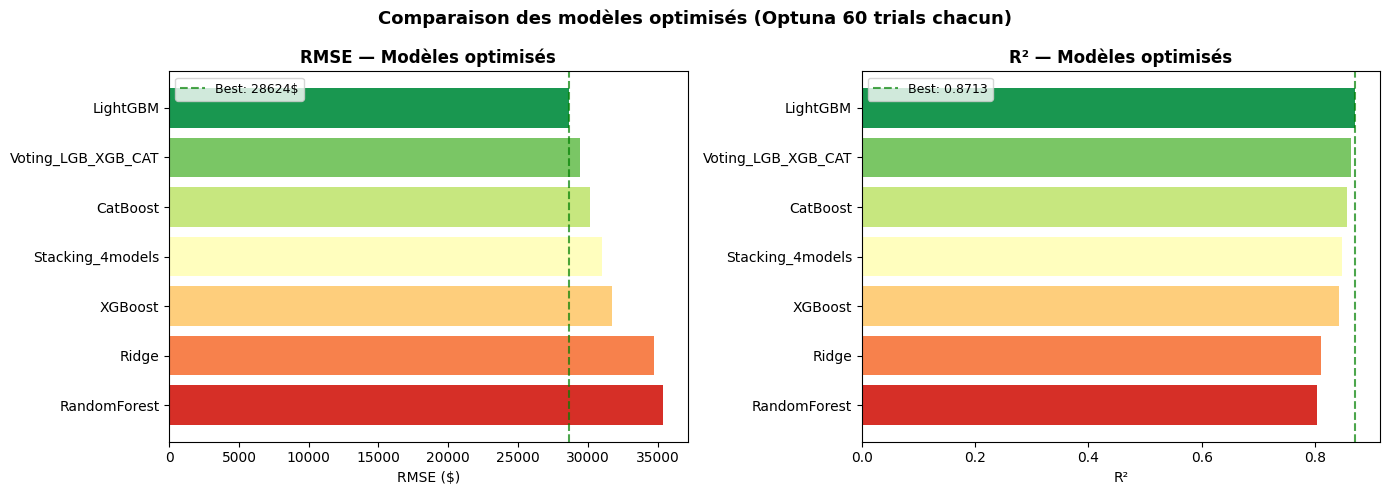

2026-06-08 12:21:58.292 | INFO     | __main__:<module>:23 - Graphique sauvegardé : reports/optimization_comparison.png


In [8]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
models_  = final_df["Modèle"].values
rmses_   = final_df["rmse"].values
r2s_     = final_df["r2"].values
palette  = plt.cm.RdYlGn_r(np.linspace(0.1, 0.9, len(models_)))

axes[0].barh(models_[::-1], rmses_[::-1], color=palette[::-1])
axes[0].set_xlabel("RMSE ($)")
axes[0].set_title("RMSE — Modèles optimisés", fontweight="bold")
axes[0].axvline(rmses_.min(), color="green", ls="--", alpha=0.7, label=f"Best: {rmses_.min():.0f}$")
axes[0].legend(fontsize=9)

axes[1].barh(models_[::-1], r2s_[::-1], color=palette[::-1])
axes[1].set_xlabel("R²")
axes[1].set_title("R² — Modèles optimisés", fontweight="bold")
axes[1].axvline(r2s_.max(), color="green", ls="--", alpha=0.7, label=f"Best: {r2s_.max():.4f}")
axes[1].legend(fontsize=9)

plt.suptitle("Comparaison des modèles optimisés (Optuna 60 trials chacun)", fontsize=13, fontweight="bold")
plt.tight_layout()
plt.savefig("../reports/optimization_comparison.png", dpi=120, bbox_inches="tight")
plt.show()
logger.info("Graphique sauvegardé : reports/optimization_comparison.png")

## 6. Analyse du meilleur modèle
### 6.1 Feature Importances

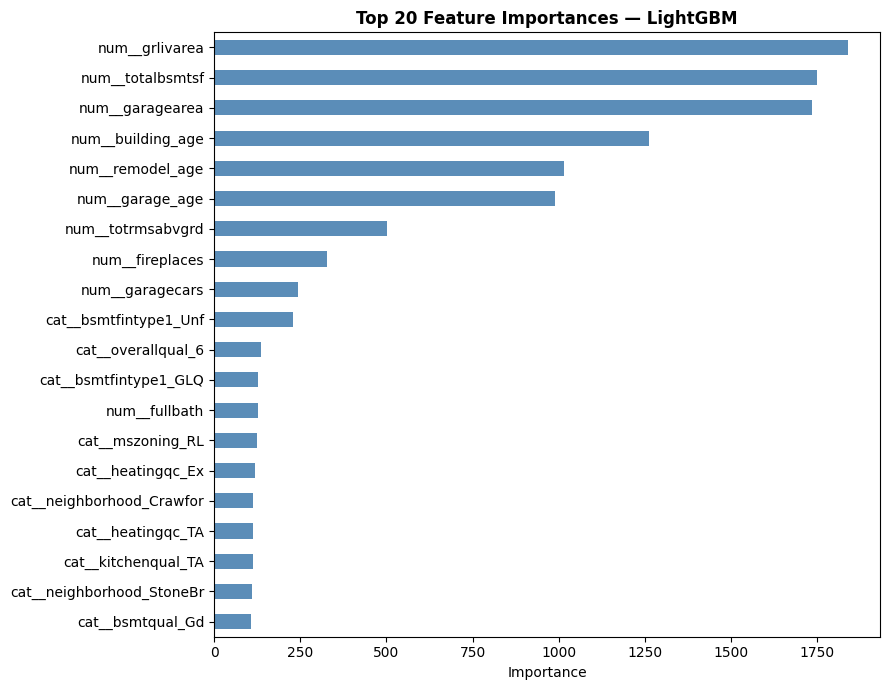

In [9]:
best_pipeline = fitted_pipelines.get(best_name) or fitted_pipelines["LightGBM"]
est = best_pipeline.named_steps["est"]
feature_names_out = best_pipeline.named_steps["pre"].get_feature_names_out()

if hasattr(est, "feature_importances_"):
    importances = pd.Series(est.feature_importances_, index=feature_names_out)
    top20 = importances.sort_values(ascending=True).tail(20)

    fig, ax = plt.subplots(figsize=(9, 7))
    top20.plot(kind="barh", ax=ax, color="#5B8DB8")
    ax.set_title(f"Top 20 Feature Importances — {best_name}", fontweight="bold")
    ax.set_xlabel("Importance")
    plt.tight_layout()
    plt.savefig("../reports/feature_importances_best.png", dpi=120, bbox_inches="tight")
    plt.show()
else:
    logger.info(f"{best_name} n'expose pas de feature_importances_")

### 6.2 Analyse des résidus

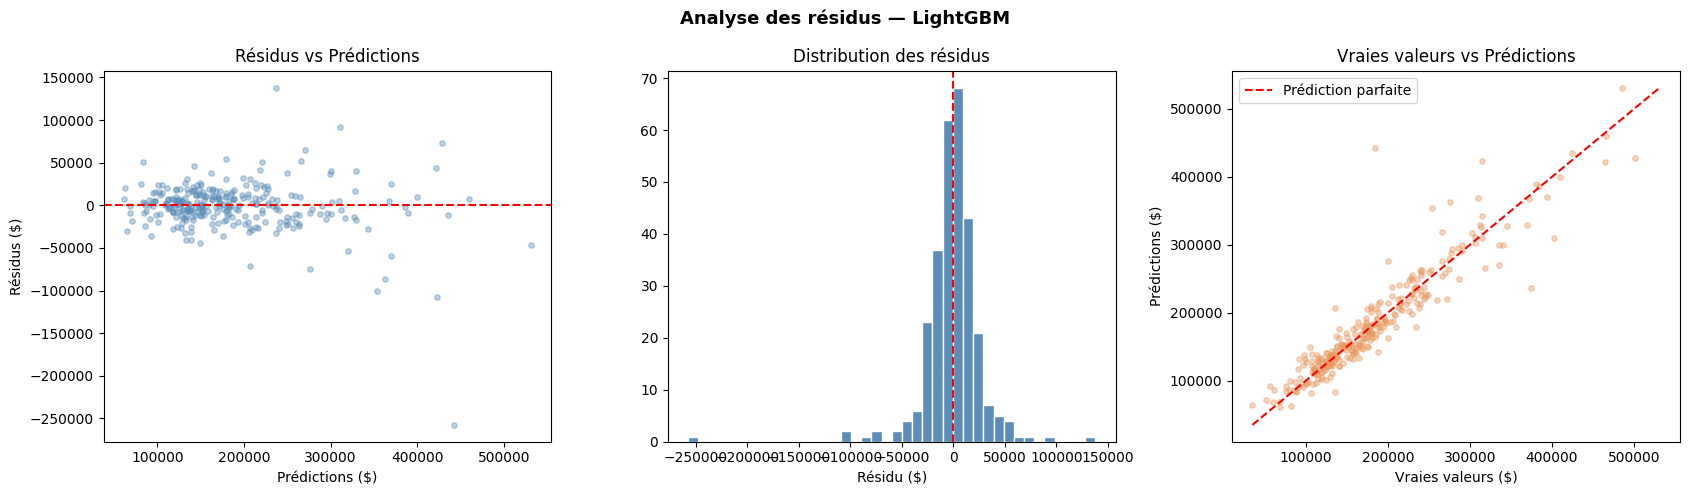

2026-06-08 12:21:58.791 | INFO     | __main__:<module>:26 - Résidus: moyenne=-935$ | std=28657$


In [10]:
preds_best = np.expm1(best_pipeline.predict(X_test))
true_vals  = np.expm1(y_log_test)
residuals  = true_vals - preds_best

fig, axes = plt.subplots(1, 3, figsize=(17, 5))

axes[0].scatter(preds_best, residuals, alpha=0.4, s=15, color="#5B8DB8")
axes[0].axhline(0, color="red", ls="--")
axes[0].set_xlabel("Prédictions ($)"); axes[0].set_ylabel("Résidus ($)")
axes[0].set_title("Résidus vs Prédictions")

axes[1].hist(residuals, bins=40, color="#5B8DB8", edgecolor="white")
axes[1].axvline(0, color="red", ls="--")
axes[1].set_xlabel("Résidu ($)"); axes[1].set_title("Distribution des résidus")

mn, mx = min(true_vals.min(), preds_best.min()), max(true_vals.max(), preds_best.max())
axes[2].scatter(true_vals, preds_best, alpha=0.4, s=15, color="#E8985E")
axes[2].plot([mn, mx], [mn, mx], "r--", label="Prédiction parfaite")
axes[2].set_xlabel("Vraies valeurs ($)"); axes[2].set_ylabel("Prédictions ($)")
axes[2].set_title("Vraies valeurs vs Prédictions"); axes[2].legend()

plt.suptitle(f"Analyse des résidus — {best_name}", fontweight="bold", fontsize=13)
plt.tight_layout()
plt.savefig("../reports/residuals_best.png", dpi=120, bbox_inches="tight")
plt.show()
logger.info(f"Résidus: moyenne={residuals.mean():.0f}$ | std={residuals.std():.0f}$")

## 7. Sauvegarde du modèle final

In [11]:
EXECUTION_DATE = pendulum.now(tz="UTC")
PROJECT_DIR    = Path.cwd().parent
MODEL_DIR      = Path(PROJECT_DIR, "models")
MODEL_DIR.mkdir(parents=True, exist_ok=True)

model_path = Path(MODEL_DIR, f"{EXECUTION_DATE.strftime('%Y%m%d')}_{MODEL_NAME}")
with open(model_path, "wb") as f:
    dill.dump(best_pipeline, f)

# Métriques DVC
import json as json_lib
with open(Path(PROJECT_DIR, "metrics.json"), "w") as f:
    json_lib.dump({
        "model": best_name,
        **best_metrics,
        "n_features": len(FEATURE_NAMES),
    }, f, indent=2)

logger.info(f"Modèle sauvegardé : {model_path}")
logger.info(f"Métriques : RMSE={best_metrics['rmse']:.0f}$ | MAE={best_metrics['mae']:.0f}$ | R²={best_metrics['r2']:.4f}")

2026-06-08 12:21:58.809 | INFO     | __main__:<module>:19 - Modèle sauvegardé : /Users/zoro008/Documents/dic3/house_price 2/models/20260608_model_house_price.dill


2026-06-08 12:21:58.809 | INFO     | __main__:<module>:20 - Métriques : RMSE=28624$ | MAE=17306$ | R²=0.8713


## 8. MLFlow UI

```bash
# Depuis le dossier notebooks/
mlflow ui
# → http://127.0.0.1:5000
```

---
## Résumé

| Étape | Contenu |
|-------|---------|
| Benchmark (nb02) | 54 runs, 20+ modèles, raw vs log-transform |
| Optuna par modèle | 60 trials × 5 modèles = 300 trials |
| Ensembles | VotingRegressor + StackingRegressor |
| Modèle final | Meilleur RMSE parmi tous les candidats |